# Command Following — Alignment & Pair Extraction EDA

**Goal:** Verify, with real data, that:
1. Audio event deduplication is working as expected (same command detected as both keep+stop, merged into one position)
2. Alternating keep/stop assumption is plausible (does the sequence look right?)
3. Timestamp alignment (Unix → EDF-relative) lands at the right sample in the .fif
4. Cropped segments actually capture the right EEG data
5. Inter-command gaps (response window duration) to understand how much data we leave on the table

In [ ]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

In [30]:
import warnings

import datetime as dt
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore")

from src.data_loading import UnifiedDataLoader
from src.data_loading import config
from src.utils.time_utils import detect_timezone_offset, unix_to_edf
from src.pipelines.command_following import (
    EPOCH_TRIM_START,
    EPOCH_TRIM_END,
    MIN_EPOCH_DURATION,
    CONTRALATERAL_MAP,
    deduplicate_and_label,
)

PATIENT_ID = "CON008"
SESSION_ID = "s_CON008_202508140000"
COMMAND_TYPES = ["left_command", "right_command"]

print("Imports OK")
print(f"EPOCH_TRIM_START = {EPOCH_TRIM_START}s | EPOCH_TRIM_END = {EPOCH_TRIM_END}s | MIN_EPOCH_DURATION = {MIN_EPOCH_DURATION}s")

Imports OK
EPOCH_TRIM_START = 0.5s | EPOCH_TRIM_END = 0.1s | MIN_EPOCH_DURATION = 1.5s


---
## 1. Load Events

In [3]:
loader = UnifiedDataLoader()

# Pull aligned events for this patient
aligned_events_path = config.ALIGNED_EVENTS_DIR / f"{PATIENT_ID}_events.parquet"
aligned_events = pd.read_parquet(aligned_events_path)

print(f"Total aligned events: {len(aligned_events)}")
print(f"Columns: {list(aligned_events.columns)}")
aligned_events.head(3)

2026-03-01 16:13:02,107 - src.data_loading.unified_data_loader - Loading unified data from unified_stimulus_results.parquet
2026-03-01 16:13:02,348 - src.data_loading.unified_data_loader - Schema validation passed
2026-03-01 16:13:02,351 - src.data_loading.unified_data_loader - Loaded 1603 trials from 14 patients


Total aligned events: 82
Columns: ['patient_id', 'session_id', 'date', 'trial_type', 'trial_id', 'start_time', 'end_time', 'duration', 'sentences', 'dc_channel', 'alignment_method', 'source_file']


,patient_id,session_id,date,trial_type,trial_id,start_time,end_time,duration,sentences,dc_channel,alignment_method,source_file
0,CON008,s_CON008_202508140000,2025-08-14,language,lt1_CON008_202508140000,1.755207e+09,1.755207e+09,15.616569,"[{'correlation_score': 0.7722566296648785, 'ev...",DC5,correlation,CON008_2025-08-14_stimulus_results.csv
1,CON008,s_CON008_202508140000,2025-08-14,left_command,lct1_CON008_202508140000,1.755207e+09,1.755208e+09,210.902308,"[{'correlation_score': 0.7880579608079086, 'ev...",DC5,commands,CON008_2025-08-14_stimulus_results.csv
2,CON008,s_CON008_202508140000,2025-08-14,language,lt2_CON008_202508140000,1.755208e+09,1.755208e+09,15.479139,"[{'correlation_score': None, 'event': '21', 'e...",DC5,correlation,CON008_2025-08-14_stimulus_results.csv


In [8]:
# Filter to command trials only
cmd_trials = aligned_events[
    (aligned_events["trial_type"].isin(COMMAND_TYPES)) &
    (aligned_events["session_id"] == SESSION_ID)
].reset_index(drop=True)
cmd_trials["num_events"] = cmd_trials["sentences"].apply(len)

print(f"Command trials found: {len(cmd_trials)}")
cmd_trials[["trial_id", "session_id", "trial_type", "start_time", "end_time", "duration", "num_events", "sentences"]]

Command trials found: 6


,trial_id,session_id,trial_type,start_time,end_time,duration,num_events,sentences
0,lct1_CON008_202508140000,s_CON008_202508140000,left_command,1.755207e+09,1.755208e+09,210.902308,30,"[{'correlation_score': 0.7880579608079086, 'ev..."
1,lct2_CON008_202508140000,s_CON008_202508140000,left_command,1.755208e+09,1.755208e+09,210.905872,27,"[{'correlation_score': 0.7630984837468283, 'ev..."
2,rct1_CON008_202508140000,s_CON008_202508140000,right_command,1.755208e+09,1.755208e+09,210.251103,26,"[{'correlation_score': 0.9775491105537824, 'ev..."
3,rct2_CON008_202508140000,s_CON008_202508140000,right_command,1.755209e+09,1.755209e+09,210.398194,26,"[{'correlation_score': 0.8020442630461192, 'ev..."
4,rct3_CON008_202508140000,s_CON008_202508140000,right_command,1.755209e+09,1.755209e+09,210.298902,25,"[{'correlation_score': 0.9235200124225696, 'ev..."
5,lct3_CON008_202508140000,s_CON008_202508140000,left_command,1.755210e+09,1.755210e+09,210.905305,27,"[{'correlation_score': 0.7863728781603301, 'ev..."


---
## 2. Inspect Raw Sentences (Before Deduplication)

Each trial has a `sentences` field: a list of audio detection dicts.  
We expect to see **both** the keep template AND stop template matching the same audio event → two entries with timestamps < 1s apart.

In [23]:
print(sentences[0].keys())
print(sentences[0]["event"])

dict_keys(['correlation_score', 'event', 'event_duration', 'event_end', 'event_start', 'onset_time', 'peak_amplitude'])
left_stop


In [34]:
for _, trial in cmd_trials.iterrows():
    sentences = trial["sentences"]
    if len(sentences) == 0:
        print(f"Trial {trial['trial_id']} ({trial['trial_type']}): NO SENTENCES")
        continue

    valid = [s for s in sentences if s.get("event_start") and s.get("event_end")]
    sorted_sents = sorted(valid, key=lambda s: s["event_start"])

    print(f"\n{'='*70}")
    print(f"Trial: {trial['trial_id']} | Type: {trial['trial_type']} | Total events: {len(sentences)} | Valid events: {len(valid)}")
    print(f"{'event_idx':>0} | {'event':>10} | {'event_start':>12} | {'event_end':>12} | {'duration':>10} | {'corr':>6}")
    print("-" * 80)
    for i, s in enumerate(sorted_sents):
        dur = s["event_end"] - s["event_start"]
        corr = s.get("correlation_score", float("nan"))
        evt_start = dt.datetime.fromtimestamp(s["event_start"])
        evt_end = dt.datetime.fromtimestamp(s["event_end"])
        print(f"{i:>9} | {s['event']:>10} |{evt_start.strftime('%H:%M:%S'):>13} | {evt_end.strftime('%H:%M:%S'):>12} | {dur:>9.2f}s | {corr:>6.3f}")


Trial: lct1_CON008_202508140000 | Type: left_command | Total events: 30 | Valid events: 30
event_idx |      event |  event_start |    event_end |   duration |   corr
--------------------------------------------------------------------------------
        0 |  left_stop |     14:35:18 |     14:35:21 |      2.93s |  0.788
        1 |  left_keep |     14:35:18 |     14:35:21 |      2.76s |  0.843
        2 |  left_keep |     14:35:31 |     14:35:34 |      2.76s |  0.760
        3 |  left_stop |     14:35:44 |     14:35:47 |      2.93s |  0.867
        4 |  left_keep |     14:35:44 |     14:35:47 |      2.76s |  0.894
        5 |  left_stop |     14:35:57 |     14:36:00 |      2.93s |  0.964
        6 |  left_keep |     14:35:57 |     14:36:00 |      2.76s |  0.957
        7 |  left_stop |     14:36:09 |     14:36:12 |      2.93s |  0.930
        8 |  left_keep |     14:36:10 |     14:36:12 |      2.76s |  0.940
        9 |  left_stop |     14:36:22 |     14:36:25 |      2.93s |  0.991
  

---
## 3. Deduplication — See How Raw → Positions Works

For each pair of consecutive raw events: if they start within **1.0s** of each other, they are merged into one position.  
Then alternating keep/stop labels are assigned starting with 'keep'.

In [40]:
MERGE_THRESHOLD = 1.0  # seconds — must match deduplicate_and_label's internal threshold


def show_deduplication(trial, start_with="keep"):
    """
    Call the real deduplicate_and_label() from command_following.py and display
    its output alongside which raw sentences were collapsed into each position.

    'merged_from' is reconstructed by checking which raw events have a start
    timestamp within MERGE_THRESHOLD of the position's start — same logic the
    function uses internally.
    """
    sentences = trial["sentences"]
    valid = [s for s in sentences if s.get("event_start") and s.get("event_end")]
    sorted_sents = sorted(valid, key=lambda s: s["event_start"])

    # --- Call the ACTUAL pipeline function ---
    positions = deduplicate_and_label(sentences, start_with=start_with)

    # Reconstruct merge groups: for each position, find raw events within threshold
    merge_log = []
    for pos in positions:
        group_indices = [
            i for i, s in enumerate(sorted_sents)
            if abs(s["event_start"] - pos["start"]) < MERGE_THRESHOLD
        ]
        group_events = [sorted_sents[i].get("event", "?") for i in group_indices]
        merge_log.append({"raw_indices": group_indices, "raw_events": group_events})

    print(f"\nTrial {trial['trial_id']} ({trial['trial_type']})")
    print(f"  Raw detections: {len(sorted_sents)} → Merged positions: {len(positions)}")
    print()
    print(f"  {'Pos':>4} | {'Label':>6} | {'start':>12} | {'end':>12} | {'dur':>7} | merged_from (raw_idx: event_name)")
    print("  " + "-" * 85)
    for idx, (pos, grp) in enumerate(zip(positions, merge_log)):
        dur = pos["end"] - pos["start"]
        merged_str = ", ".join(f"{i}:{e}" for i, e in zip(grp["raw_indices"], grp["raw_events"]))
        pos_start = dt.datetime.fromtimestamp(pos["start"])
        pos_end = dt.datetime.fromtimestamp(pos["end"])
        print(f"  {idx:>4} | {pos['type']:>6} | {pos_start.strftime('%H:%M:%S'):>12} | {pos_end.strftime('%H:%M:%S'):>12} | {dur:>7.2f}s | [{merged_str}]")

    return positions


all_positions = {}
for _, trial in cmd_trials.iterrows():
    positions = show_deduplication(trial)
    all_positions[trial["trial_id"]] = (trial, positions)


Trial lct1_CON008_202508140000 (left_command)
  Raw detections: 30 → Merged positions: 16

   Pos |  Label |        start |          end |     dur | merged_from (raw_idx: event_name)
  -------------------------------------------------------------------------------------
     0 |   keep |     14:35:18 |     14:35:21 |    2.93s | [0:left_stop, 1:left_keep]
     1 |   stop |     14:35:31 |     14:35:34 |    2.76s | [2:left_keep]
     2 |   keep |     14:35:44 |     14:35:47 |    2.93s | [3:left_stop, 4:left_keep]
     3 |   stop |     14:35:57 |     14:36:00 |    2.93s | [5:left_stop, 6:left_keep]
     4 |   keep |     14:36:09 |     14:36:12 |    2.93s | [7:left_stop, 8:left_keep]
     5 |   stop |     14:36:22 |     14:36:25 |    2.93s | [9:left_stop, 10:left_keep]
     6 |   keep |     14:36:35 |     14:36:38 |    2.93s | [11:left_stop, 12:left_keep]
     7 |   stop |     14:36:48 |     14:36:51 |    2.93s | [13:left_stop, 14:left_keep]
     8 |   keep |     14:37:01 |     14:37:04 | 

---
## 4. Inter-Command Gap Analysis

**Key question:** How long is the period between the END of a keep/stop audio and the START of the next command?  
This is the **response window** — the period the brain actually responds in.  
Currently we're only analyzing the audio window (~3s). The response window is the valuable signal.

In [36]:
print("Inter-command gap analysis (response window duration)\n")
all_gaps = []
all_audio_durs = []

for trial_id, (trial, positions) in all_positions.items():
    print(f"Trial {trial_id} ({trial['trial_type']})")
    print(f"  {'Pos':>4} | {'Label':>6} | {'audio_dur':>10} | {'gap_to_next':>12} | {'full_window':>12}")
    print("  " + "-" * 60)
    for idx, pos in enumerate(positions):
        audio_dur = pos["end"] - pos["start"]
        all_audio_durs.append(audio_dur)
        if idx + 1 < len(positions):
            gap = positions[idx + 1]["start"] - pos["end"]
            full_window = positions[idx + 1]["start"] - pos["start"]
            all_gaps.append(gap)
            print(f"  {idx:>4} | {pos['type']:>6} | {audio_dur:>10.2f}s | {gap:>12.2f}s | {full_window:>12.2f}s")
        else:
            print(f"  {idx:>4} | {pos['type']:>6} | {audio_dur:>10.2f}s | {'(last)':>12} | {'?':>12}")
    print()

print(f"\nSummary across all positions:")
print(f"  Audio duration: mean={np.mean(all_audio_durs):.2f}s | min={np.min(all_audio_durs):.2f}s | max={np.max(all_audio_durs):.2f}s")
if all_gaps:
    print(f"  Gap to next:    mean={np.mean(all_gaps):.2f}s | min={np.min(all_gaps):.2f}s | max={np.max(all_gaps):.2f}s")
    print(f"  \n  ⟹ Current analysis uses ~{np.mean(all_audio_durs) - EPOCH_TRIM_START - EPOCH_TRIM_END:.2f}s of signal")
    print(f"     Response window gives additional ~{np.mean(all_gaps):.2f}s")
    print(f"     Extended window (audio+response) = ~{np.mean(all_audio_durs) + np.mean(all_gaps) - EPOCH_TRIM_START - EPOCH_TRIM_END:.2f}s")

Inter-command gap analysis (response window duration)

Trial lct1_CON008_202508140000 (left_command)
   Pos |  Label |  audio_dur |  gap_to_next |  full_window
  ------------------------------------------------------------
     0 |   keep |       2.93s |        10.23s |        13.15s
     1 |   stop |       2.76s |         9.98s |        12.74s
     2 |   keep |       2.93s |        10.04s |        12.97s
     3 |   stop |       2.93s |         9.96s |        12.88s
     4 |   keep |       2.93s |        10.07s |        12.99s
     5 |   stop |       2.93s |         9.97s |        12.89s
     6 |   keep |       2.93s |        10.06s |        12.99s
     7 |   stop |       2.93s |         9.97s |        12.90s
     8 |   keep |       2.93s |        10.05s |        12.98s
     9 |   stop |       2.93s |         9.97s |        12.90s
    10 |   keep |       2.93s |        10.32s |        13.25s
    11 |   stop |       2.93s |         9.70s |        12.63s
    12 |   keep |       2.93s |  

---
## 5. Timeline Plot — All Positions per Trial

Visualize keep/stop positions on a timeline to check if the alternating pattern looks reasonable.

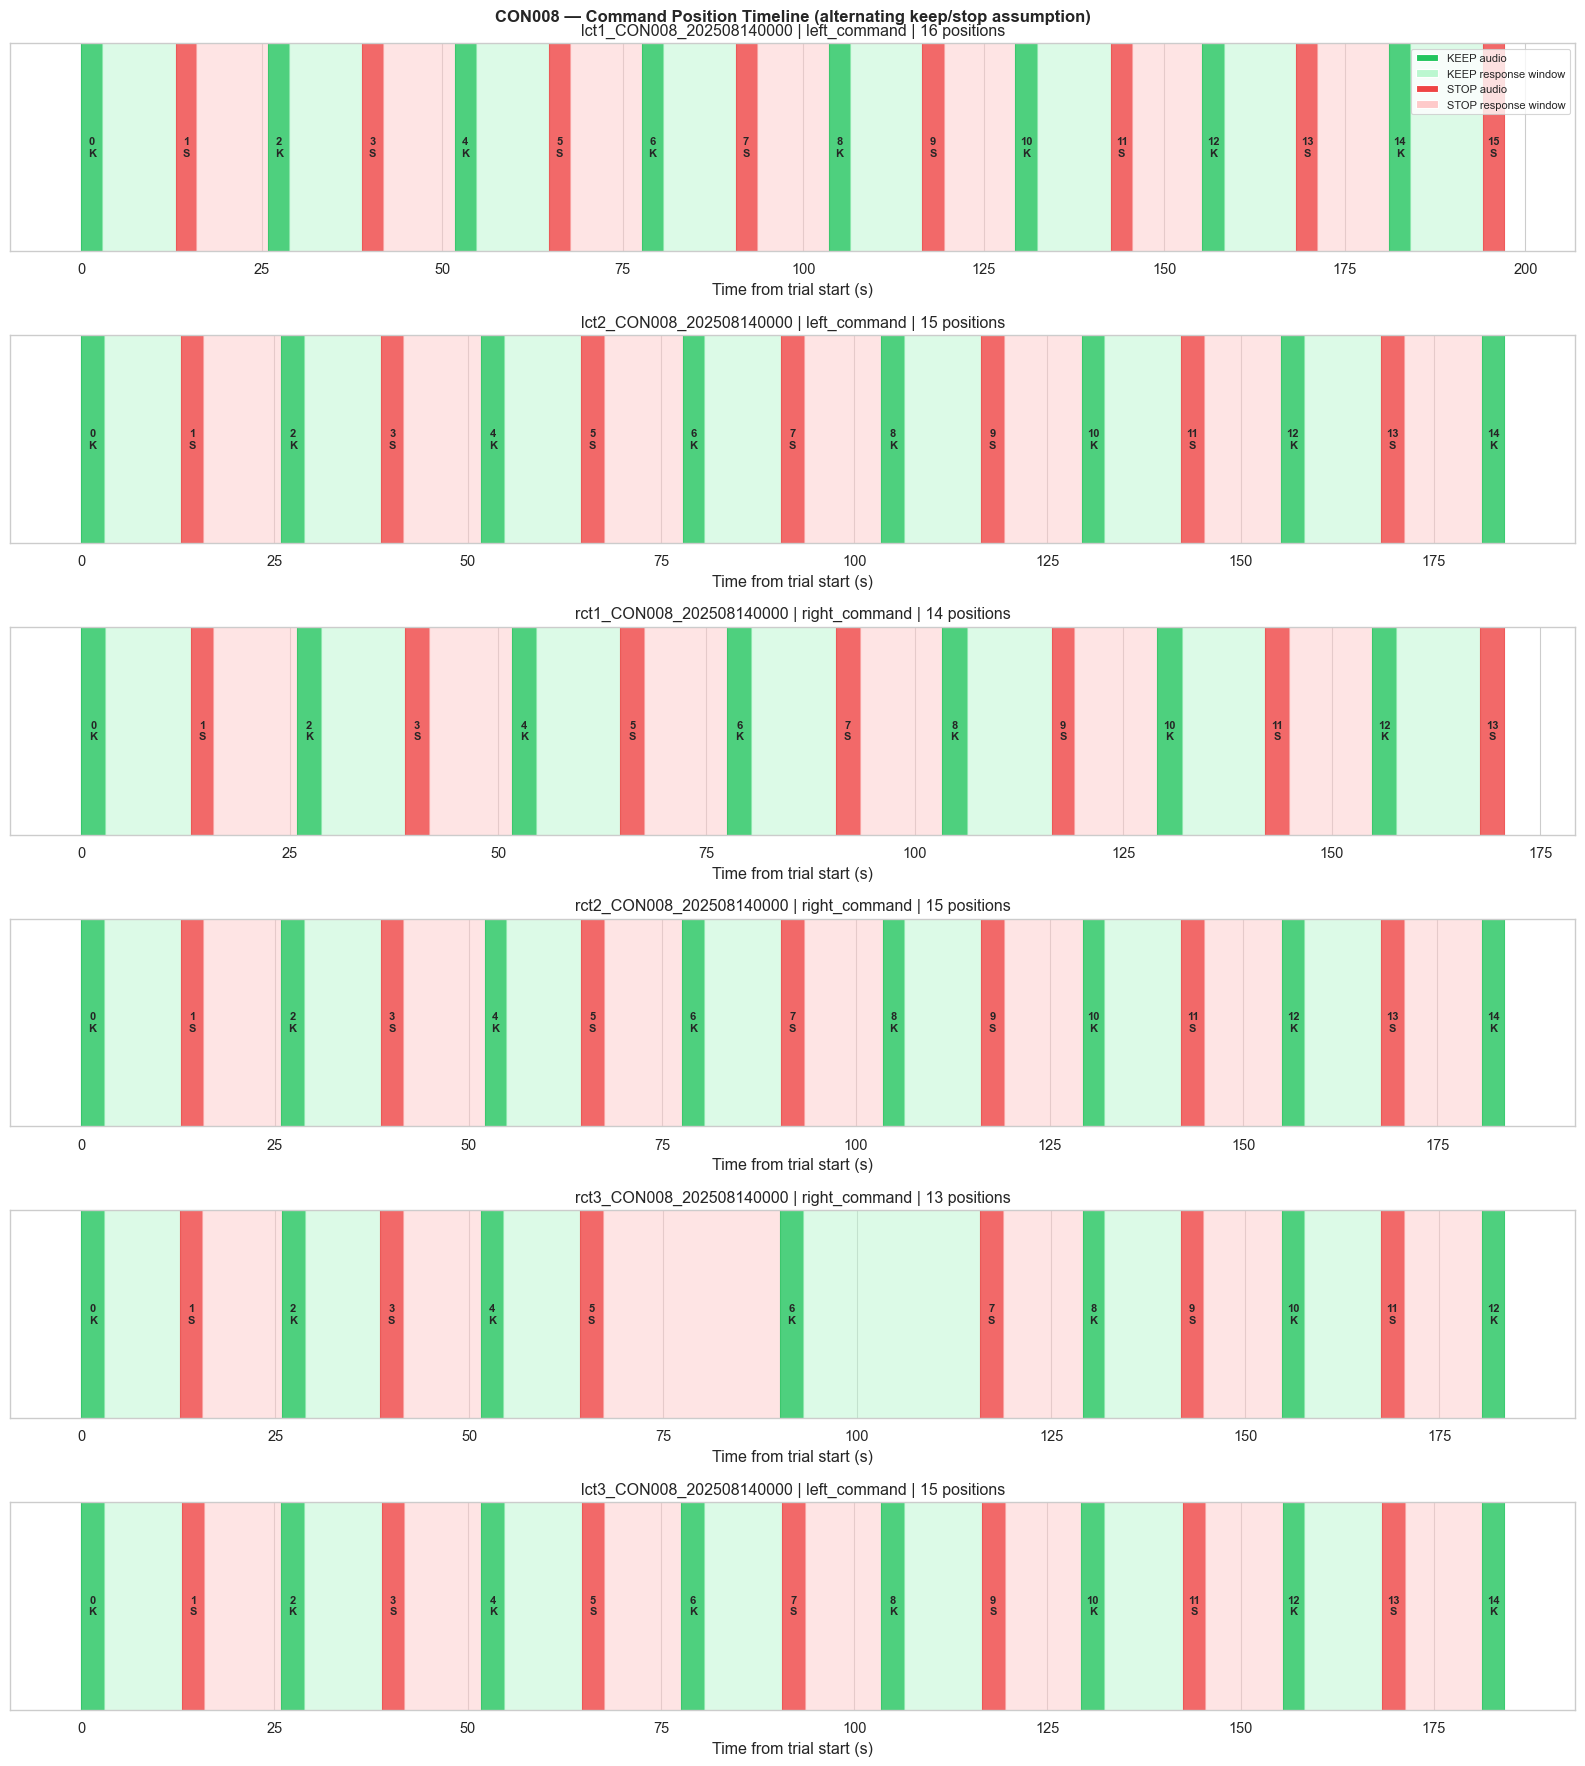

In [37]:
n_trials = len(all_positions)
fig, axes = plt.subplots(n_trials, 1, figsize=(16, 3 * n_trials))
if n_trials == 1:
    axes = [axes]

KEEP_COLOR = "#22c55e"
STOP_COLOR = "#ef4444"
RESPONSE_KEEP_COLOR = "#bbf7d0"
RESPONSE_STOP_COLOR = "#fecaca"

for ax, (trial_id, (trial, positions)) in zip(axes, all_positions.items()):
    if not positions:
        ax.set_title(f"{trial_id} — no positions")
        continue

    # Shift to 0-based time for readability
    t0 = positions[0]["start"]

    for idx, pos in enumerate(positions):
        color = KEEP_COLOR if pos["type"] == "keep" else STOP_COLOR
        resp_color = RESPONSE_KEEP_COLOR if pos["type"] == "keep" else RESPONSE_STOP_COLOR
        s = pos["start"] - t0
        e = pos["end"] - t0

        # Audio command span
        ax.axvspan(s, e, color=color, alpha=0.8, label=pos["type"] if idx < 2 else "")

        # Response window (until next command starts)
        if idx + 1 < len(positions):
            next_s = positions[idx + 1]["start"] - t0
            ax.axvspan(e, next_s, color=resp_color, alpha=0.5)

        # Label each position
        mid = (s + e) / 2
        ax.text(mid, 0.5, f"{idx}\n{pos['type'][0].upper()}", ha="center", va="center",
                fontsize=8, fontweight="bold", transform=ax.get_xaxis_transform())

    ax.set_xlabel("Time from trial start (s)")
    ax.set_yticks([])
    ax.set_title(f"{trial_id} | {trial['trial_type']} | {len(positions)} positions")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=KEEP_COLOR, label="KEEP audio"),
    Patch(facecolor=RESPONSE_KEEP_COLOR, label="KEEP response window"),
    Patch(facecolor=STOP_COLOR, label="STOP audio"),
    Patch(facecolor=RESPONSE_STOP_COLOR, label="STOP response window"),
]
axes[0].legend(handles=legend_elements, loc="upper right", fontsize=8)
plt.suptitle(f"{PATIENT_ID} — Command Position Timeline (alternating keep/stop assumption)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. Load .fif Epochs and Test Timestamp Alignment

**What we're verifying:**  
The pipeline converts each trial's `start_time` (Unix) → EDF-relative seconds → sample index in the .fif.  
We check that the matched epoch's sample offset lands within tolerance (0.5s = `sample_tolerance`).

In [38]:
# Load .fif for each trial_type
fif_epochs = {}
for trial_type in COMMAND_TYPES:
    fif_path = config.EPOCHS_DIR / PATIENT_ID / SESSION_ID / f"{trial_type}-epo.fif"
    if fif_path.exists():
        epochs = mne.read_epochs(str(fif_path), preload=True, verbose=False)
        fif_epochs[trial_type] = epochs
        print(f"{trial_type}: {len(epochs)} epochs | sfreq={epochs.info['sfreq']}Hz | "
              f"duration={len(epochs.times)/epochs.info['sfreq']:.2f}s per epoch")
        print(f"  meas_date (EDF start): {epochs.info['meas_date']}")
    else:
        print(f"NOT FOUND: {fif_path}")

left_command: 2 epochs | sfreq=512.0Hz | duration=200.00s per epoch
  meas_date (EDF start): 2025-08-14 14:25:18+00:00
right_command: 2 epochs | sfreq=512.0Hz | duration=200.00s per epoch
  meas_date (EDF start): 2025-08-14 14:25:18+00:00


In [46]:
# Test alignment for each trial
session_trials = aligned_events[aligned_events["session_id"] == SESSION_ID]

print("Timestamp Alignment Test")
print("=" * 80)

for trial_type, all_epochs in fif_epochs.items():
    print(f"\n--- {trial_type} ---")
    
    edf_start_unix = all_epochs.info["meas_date"].timestamp()
    sfreq = all_epochs.info["sfreq"]
    sample_tolerance = int(0.5 * sfreq)  # 0.5s tolerance
    tz_offset = detect_timezone_offset(all_epochs, session_trials)
    
    print(f"  EDF start (Unix): {edf_start_unix:.2f}")
    print(f"  Timezone offset: {tz_offset:.1f}s ({tz_offset/3600:.2f}h)")
    print(f"  Sample tolerance: {sample_tolerance} samples ({0.5:.1f}s)")
    print()
    
    trials_of_type = cmd_trials[cmd_trials["trial_type"] == trial_type]
    
    print(f"  {'Trial':>24} | {'start_unix':>14} | {'start_edf':>10} | {'expected_samp':>14} | {'best_samp':>10} | {'diff_samp':>10} | {'diff_sec':>10} | {'match?':>7}")
    print("  " + "-" * 120)
    
    for _, trial in trials_of_type.iterrows():
        start_edf = float(trial["start_time"]) - edf_start_unix + tz_offset
        if np.isnan(start_edf) or start_edf < 0:
            print(f"  {trial['trial_id']:>42} | SKIP (start_edf={start_edf:.2f} < 0 or NaN)")
            continue
        
        expected_samp = int(np.round(start_edf * sfreq))
        diffs = np.abs(all_epochs.events[:, 0] - expected_samp)
        match_idx = np.argmin(diffs)
        best_samp = all_epochs.events[match_idx, 0]
        diff_samp = int(diffs[match_idx])
        diff_sec = diff_samp / sfreq
        matched = diff_samp <= sample_tolerance
        
        print(f"  {trial['trial_id']:>12} | {float(trial['start_time']):>14.2f} | {start_edf:>10.2f} | {expected_samp:>14d} | {best_samp:>10d} | {diff_samp:>10d} | {diff_sec:>9.3f}s | {'✓ OK' if matched else '✗ MISS':>7}")

2026-03-01 17:03:10,076 - src.utils.time_utils - Timezone offset detected: -7.0 hours
2026-03-01 17:03:10,090 - src.utils.time_utils - Timezone offset detected: -7.0 hours


Timestamp Alignment Test

--- left_command ---
  EDF start (Unix): 1755181518.00
  Timezone offset: -25200.0s (-7.00h)
  Sample tolerance: 256 samples (0.5s)

                     Trial |     start_unix |  start_edf |  expected_samp |  best_samp |  diff_samp |   diff_sec |  match?
  ------------------------------------------------------------------------------------------------------------------------
  lct1_CON008_202508140000 |  1755207313.76 |     595.76 |         305030 |     305030 |          0 |     0.000s |    ✓ OK
  lct2_CON008_202508140000 |  1755207783.15 |    1065.15 |         545359 |     305030 |     240329 |   469.393s |  ✗ MISS
  lct3_CON008_202508140000 |  1755209558.91 |    2840.91 |        1454544 |    1454544 |          0 |     0.000s |    ✓ OK

--- right_command ---
  EDF start (Unix): 1755181518.00
  Timezone offset: -25200.0s (-7.00h)
  Sample tolerance: 256 samples (0.5s)

                     Trial |     start_unix |  start_edf |  expected_samp |  best_samp |  d

---
## 7. Crop Test — What Do We Actually Get?

For each matched epoch, try cropping the keep and stop segments (current behavior: audio-only window).  
Report:
- How many crops succeed vs fail
- Actual crop durations
- Whether the crop duration meets `MIN_EPOCH_DURATION`
- What the EXTENDED crop (using next command start as endpoint) would give

In [52]:
def try_crop(epochs_1, position, tz_offset, edf_start_unix, segment_end_unix=None):
    """Attempt to crop a segment. Returns (cropped_epochs_or_None, tmin, tmax, duration)."""
    event_edf_time = epochs_1.events[0, 0] / epochs_1.info["sfreq"]
    seg_start_edf = unix_to_edf(position["start"], edf_start_unix=edf_start_unix, timezone_offset=tz_offset)
    
    # Use segment_end_unix if provided (extended window), otherwise use position["end"]
    end_unix = segment_end_unix if segment_end_unix is not None else position["end"]
    seg_end_edf = unix_to_edf(end_unix, edf_start_unix=edf_start_unix, timezone_offset=tz_offset)
    
    tmin = (seg_start_edf - event_edf_time) + EPOCH_TRIM_START
    tmax = (seg_end_edf - event_edf_time) - EPOCH_TRIM_END
    dur = tmax - tmin
    
    if dur < MIN_EPOCH_DURATION:
        return None, tmin, tmax, dur, "too short"
    if tmin < epochs_1.times[0] or tmax > epochs_1.times[-1]:
        return None, tmin, tmax, dur, f"out of bounds [{epochs_1.times[0]:.2f}, {epochs_1.times[-1]:.2f}]"
    
    try:
        seg = epochs_1.copy().crop(tmin=tmin, tmax=tmax)
        return seg, tmin, tmax, dur, "OK"
    except Exception as ex:
        return None, tmin, tmax, dur, f"EXCEPTION: {ex}"


print("Crop Simulation (Current: audio-only | Extended: audio+response window)")
print("=" * 100)

pair_summary = []

for trial_type, all_epochs in fif_epochs.items():
    print(f"\n--- {trial_type} ---")
    edf_start_unix = all_epochs.info["meas_date"].timestamp()
    sfreq = all_epochs.info["sfreq"]
    sample_tolerance = int(0.5 * sfreq)
    tz_offset = detect_timezone_offset(all_epochs, session_trials)
    trials_of_type = cmd_trials[cmd_trials["trial_type"] == trial_type]
    
    for _, trial in trials_of_type.iterrows():
        start_edf = float(trial["start_time"]) - edf_start_unix + tz_offset
        if np.isnan(start_edf) or start_edf < 0:
            continue
        
        expected_samp = int(np.round(start_edf * sfreq))
        diffs = np.abs(all_epochs.events[:, 0] - expected_samp)
        match_idx = np.argmin(diffs)
        if diffs[match_idx] > sample_tolerance:
            print(f"  Trial {trial['trial_id']}: NO MATCHING EPOCH")
            continue
        
        epoch_1 = all_epochs[match_idx]
        trial_id = trial["trial_id"]
        positions = all_positions.get(trial_id, (None, []))[1]
        keep_positions = positions[0::2]
        stop_positions = positions[1::2]
        
        print(f"\n  Trial {trial_id} | {len(keep_positions)} keep / {len(stop_positions)} stop positions")
        print(f"  {'pair':>5} | {'label':>6} | {'curr_dur':>9} | {'curr_ok':>8} | {'ext_dur':>9} | {'ext_ok':>8} | {'extra_data':>10}")
        print("  " + "-" * 72)
        
        for k, (keep_pos, stop_pos) in enumerate(zip(keep_positions, stop_positions)):
            # Next keep start (for extended stop window)
            stop_ext_end = keep_positions[k + 1]["start"] if k + 1 < len(keep_positions) else None
            keep_ext_end = stop_pos["start"]  # keep extended window ends at stop audio start
            
            # KEEP: current vs extended
            _, km_t, km_x, km_dur, km_status = try_crop(epoch_1, keep_pos, tz_offset, edf_start_unix)
            _, ke_t, ke_x, ke_dur, ke_status = try_crop(epoch_1, keep_pos, tz_offset, edf_start_unix, segment_end_unix=keep_ext_end)
            extra_keep = ke_dur - km_dur if ke_dur > 0 else 0
            print(f"  {k:>5} | {'keep':>6} | {km_dur:>9.2f}s | {km_status:>8} | {ke_dur:>9.2f}s | {ke_status:>8} | +{extra_keep:.2f}s")
            
            # STOP: current vs extended
            _, sm_t, sm_x, sm_dur, sm_status = try_crop(epoch_1, stop_pos, tz_offset, edf_start_unix)
            if stop_ext_end is not None:
                _, se_t, se_x, se_dur, se_status = try_crop(epoch_1, stop_pos, tz_offset, edf_start_unix, segment_end_unix=stop_ext_end)
                extra_stop = se_dur - sm_dur if se_dur > 0 else 0
                print(f"  {k:>5} | {'stop':>6} | {sm_dur:>9.2f}s | {sm_status:>8} | {se_dur:>9.2f}s | {se_status:>8} | +{extra_stop:.2f}s")
            else:
                print(f"  {k:>5} | {'stop':>6} | {sm_dur:>9.2f}s | {sm_status:>8} | {'N/A':>9} | {'(last)':>8} |")
            
            pair_summary.append({
                "trial": trial_id, "type": trial_type, "pair": k,
                "keep_curr_dur": km_dur, "keep_curr_ok": km_status == "OK",
                "keep_ext_dur": ke_dur, "keep_ext_ok": ke_status == "OK",
                "stop_curr_dur": sm_dur, "stop_curr_ok": sm_status == "OK",
                # stop_ext is None for the last pair (no following keep to bound it)
                "stop_ext_dur": se_dur if stop_ext_end is not None else np.nan,
                "stop_ext_ok": (se_status == "OK") if stop_ext_end is not None else False,
            })
        
        # Orphaned keep (if positions count is odd)
        if len(keep_positions) > len(stop_positions):
            orphan = keep_positions[-1]
            _, _, _, orphan_dur, orphan_status = try_crop(epoch_1, orphan, tz_offset, edf_start_unix)
            print(f"  {'--':>5} | {'ORPHAN':>6} | {orphan_dur:>9.2f}s | {orphan_status:>8} | (no pair)")

2026-03-01 17:08:55,892 - src.utils.time_utils - Timezone offset detected: -7.0 hours


Crop Simulation (Current: audio-only | Extended: audio+response window)

--- left_command ---

  Trial lct1_CON008_202508140000 | 8 keep / 8 stop positions
   pair |  label |  curr_dur |  curr_ok |   ext_dur |   ext_ok | extra_data
  ------------------------------------------------------------------------
      0 |   keep |      2.33s |       OK |     12.55s |       OK | +10.23s
      0 |   stop |      2.16s |       OK |     12.14s |       OK | +9.98s
      1 |   keep |      2.33s |       OK |     12.37s |       OK | +10.04s
      1 |   stop |      2.33s |       OK |     12.28s |       OK | +9.96s
      2 |   keep |      2.33s |       OK |     12.39s |       OK | +10.07s
      2 |   stop |      2.33s |       OK |     12.29s |       OK | +9.97s
      3 |   keep |      2.33s |       OK |     12.39s |       OK | +10.06s
      3 |   stop |      2.33s |       OK |     12.30s |       OK | +9.97s
      4 |   keep |      2.33s |       OK |     12.38s |       OK | +10.05s
      4 |   stop |    

2026-03-01 17:08:56,211 - src.utils.time_utils - Timezone offset detected: -7.0 hours


      7 |   keep |      2.33s |       OK |     12.40s |       OK | +10.07s
      7 |   stop |      2.33s | out of bounds [0.00, 200.00] |       N/A |   (last) |
  Trial lct2_CON008_202508140000: NO MATCHING EPOCH

  Trial lct3_CON008_202508140000 | 8 keep / 7 stop positions
   pair |  label |  curr_dur |  curr_ok |   ext_dur |   ext_ok | extra_data
  ------------------------------------------------------------------------
      0 |   keep |      2.33s |       OK |     12.40s |       OK | +10.07s
      0 |   stop |      2.33s |       OK |     12.29s |       OK | +9.96s
      1 |   keep |      2.33s |       OK |     12.39s |       OK | +10.06s
      1 |   stop |      2.33s |       OK |     12.30s |       OK | +9.97s
      2 |   keep |      2.33s |       OK |     12.38s |       OK | +10.06s
      2 |   stop |      2.33s |       OK |     12.29s |       OK | +9.96s
      3 |   keep |      2.33s |       OK |     12.40s |       OK | +10.07s
      3 |   stop |      2.33s |       OK |     12.28

In [53]:
# Summary stats
df_summary = pd.DataFrame(pair_summary)
if not df_summary.empty:
    print("\nCrop Success Rate Summary:")
    print(f"  Total pairs attempted: {len(df_summary)}")
    print(f"  Keep (current audio-only): {df_summary['keep_curr_ok'].sum()}/{len(df_summary)} succeed | avg dur = {df_summary.loc[df_summary['keep_curr_ok'], 'keep_curr_dur'].mean():.2f}s")
    print(f"  Keep (extended window):    {df_summary['keep_ext_ok'].sum()}/{len(df_summary)} succeed | avg dur = {df_summary.loc[df_summary['keep_ext_ok'], 'keep_ext_dur'].mean():.2f}s")
    print(f"  Stop (current audio-only): {df_summary['stop_curr_ok'].sum()}/{len(df_summary)} succeed | avg dur = {df_summary.loc[df_summary['stop_curr_ok'], 'stop_curr_dur'].mean():.2f}s")
    print(f"  Stop (extended window):    {df_summary['stop_ext_ok'].sum()}/{len(df_summary)} succeed | avg dur = {df_summary.loc[df_summary['stop_ext_ok'], 'stop_ext_dur'].mean():.2f}s")
    print()
    n_welch_windows_current = df_summary.loc[df_summary['keep_curr_ok'], 'keep_curr_dur'].mean() / 2.0
    n_welch_windows_extended = df_summary.loc[df_summary['keep_ext_ok'], 'keep_ext_dur'].mean() / 2.0
    print(f"  Welch windows per segment (2s window, 50% overlap):")
    print(f"    Current:  ~{n_welch_windows_current:.1f} windows per pair")
    print(f"    Extended: ~{n_welch_windows_extended:.1f} windows per pair")


Crop Success Rate Summary:
  Total pairs attempted: 29
  Keep (current audio-only): 29/29 succeed | avg dur = 2.29s
  Keep (extended window):    29/29 succeed | avg dur = 12.35s
  Stop (current audio-only): 27/29 succeed | avg dur = 2.29s
  Stop (extended window):    27/29 succeed | avg dur = 12.30s

  Welch windows per segment (2s window, 50% overlap):
    Current:  ~1.1 windows per pair
    Extended: ~6.2 windows per pair


---
## 8. EEG Power Check — Does Alpha/Beta Actually Differ in Keep vs Stop?

Quick sanity check: compute mean alpha (8-13 Hz) and beta (13-30 Hz) power for keep vs stop segments.  
Expected: keep power < stop power in the contralateral channel (ERD = desynchronization).

In [63]:
from scipy.signal import hilbert, butter, filtfilt

def band_power_dB(data_2d, sfreq, fmin, fmax):
    """Mean band power (dB) for 2D array (n_channels, n_times)."""
    nyq = sfreq / 2
    b, a = butter(4, [fmin / nyq, fmax / nyq], btype="band")
    filtered = filtfilt(b, a, data_2d, axis=-1)
    power = np.mean(np.abs(hilbert(filtered, axis=-1)) ** 2, axis=-1)  # (n_channels,)
    return 10 * np.log10(np.maximum(power, 1e-30))


print("Alpha (8-13 Hz) and Beta (13-30 Hz) power: Keep vs Stop")
print("Positive diff (Stop - Keep) = desynchronization during keep (ERD)")
print("=" * 80)

for trial_type, all_epochs in fif_epochs.items():
    edf_start_unix = all_epochs.info["meas_date"].timestamp()
    sfreq = all_epochs.info["sfreq"]
    sample_tolerance = int(0.5 * sfreq)
    tz_offset = detect_timezone_offset(all_epochs, session_trials)
    trials_of_type = cmd_trials[cmd_trials["trial_type"] == trial_type]
    ch_names = all_epochs.ch_names
    
    # Restrict to ROI channels if present
    roi = [c for c in ["C3", "C4", "Cz"] if c in ch_names]
    contra_ch = CONTRALATERAL_MAP.get(trial_type.split("_")[0])
    
    print(f"\n{trial_type} | ROI: {roi} | Contralateral: {contra_ch}")
    
    keep_alpha, keep_beta, stop_alpha, stop_beta = [], [], [], []

    for _, trial in trials_of_type.iterrows():
        start_edf = float(trial["start_time"]) - edf_start_unix + tz_offset
        if np.isnan(start_edf) or start_edf < 0:
            continue
        expected_samp = int(np.round(start_edf * sfreq))
        diffs = np.abs(all_epochs.events[:, 0] - expected_samp)
        match_idx = np.argmin(diffs)
        if diffs[match_idx] > sample_tolerance:
            continue
        epoch_1 = all_epochs[match_idx]
        trial_id = trial["trial_id"]
        positions = all_positions.get(trial_id, (None, []))[1]
        keep_positions = positions[0::2]
        stop_positions = positions[1::2]

        for k, (keep_pos, stop_pos) in enumerate(zip(keep_positions, stop_positions)):
            keep_ext_end = stop_pos["start"]
            stop_ext_end = keep_positions[k + 1]["start"] if k + 1 < len(keep_positions) else None

            kseg, *_ = try_crop(epoch_1, keep_pos, tz_offset, edf_start_unix, segment_end_unix=keep_ext_end)
            if stop_ext_end:
                sseg, *_ = try_crop(epoch_1, stop_pos, tz_offset, edf_start_unix, segment_end_unix=stop_ext_end)
            else:
                sseg, *_ = try_crop(epoch_1, stop_pos, tz_offset, edf_start_unix)

            if kseg is None or sseg is None:
                continue

            # Restrict to ROI
            kseg_roi = kseg.copy().pick(roi)
            sseg_roi = sseg.copy().pick(roi)

            kd = kseg_roi.get_data()[0]  # (n_channels, n_times)
            sd = sseg_roi.get_data()[0]

            keep_alpha.append(band_power_dB(kd, sfreq, 8, 13))
            keep_beta.append(band_power_dB(kd, sfreq, 13, 30))
            stop_alpha.append(band_power_dB(sd, sfreq, 8, 13))
            stop_beta.append(band_power_dB(sd, sfreq, 13, 30))

    if not keep_alpha:
        print("  No valid pairs found.")
        continue

    ka = np.array(keep_alpha)   # (n_pairs, n_channels)
    kb = np.array(keep_beta)
    sa = np.array(stop_alpha)
    sb = np.array(stop_beta)

    roi_after = kseg_roi.ch_names
    print(f"  N valid pairs: {len(ka)}")
    print(f"  {'Channel':>8} | {'Keep α (dB)':>13} | {'Stop α (dB)':>13} | {'Diff (S-K)':>18} | {'Keep β (dB)':>13} | {'Stop β (dB)':>13} | {'Diff (S-K)':>12}")
    print("  " + "-" * 120)
    for ci, ch in enumerate(roi_after):
        mark = " ← contra" if ch == contra_ch else ""
        alpha_diff = np.mean(sa[:, ci]) - np.mean(ka[:, ci])
        beta_diff = np.mean(sb[:, ci]) - np.mean(kb[:, ci])
        erd_dir_a = "↑ ERD " if alpha_diff > 0 else "↓ sync"
        erd_dir_b = "↑ ERD " if beta_diff > 0 else "↓ sync"
        print(f"  {ch:>8} | {np.mean(ka[:, ci]):>13.3f} | {np.mean(sa[:, ci]):>13.3f} | {alpha_diff:>+11f} {erd_dir_a} | {np.mean(kb[:, ci]):>13.3f} | {np.mean(sb[:, ci]):>13.3f} | {beta_diff:>+11f} {erd_dir_b}{mark}")

2026-03-01 17:13:25,845 - src.utils.time_utils - Timezone offset detected: -7.0 hours


Alpha (8-13 Hz) and Beta (13-30 Hz) power: Keep vs Stop
Positive diff (Stop - Keep) = desynchronization during keep (ERD)

left_command | ROI: ['C3', 'C4', 'Cz'] | Contralateral: C4


2026-03-01 17:13:27,064 - src.utils.time_utils - Timezone offset detected: -7.0 hours


  N valid pairs: 14
   Channel |   Keep α (dB) |   Stop α (dB) |         Diff (S-K) |   Keep β (dB) |   Stop β (dB) |   Diff (S-K)
  ------------------------------------------------------------------------------------------------------------------------
        C3 |      -112.024 |      -112.106 |   -0.081451 ↓ sync |      -110.700 |      -110.926 |   -0.226800 ↓ sync
        C4 |      -114.057 |      -113.816 |   +0.241183 ↑ ERD  |      -112.302 |      -112.158 |   +0.144067 ↑ ERD  ← contra
        Cz |      -117.599 |      -117.495 |   +0.104088 ↑ ERD  |      -114.031 |      -114.125 |   -0.093458 ↓ sync

right_command | ROI: ['C3', 'C4', 'Cz'] | Contralateral: C3
  N valid pairs: 13
   Channel |   Keep α (dB) |   Stop α (dB) |         Diff (S-K) |   Keep β (dB) |   Stop β (dB) |   Diff (S-K)
  ------------------------------------------------------------------------------------------------------------------------
        C3 |      -110.546 |      -110.547 |   -0.001495 ↓ sync |      